# AdapTrap - Three-Checkpoint Continual Learning (Batches 1, 2, 3)

Same structure and output style as `02_continual_learning.ipynb`, extended from two checkpoints
to three, using `CICHoneynet_July10-16.csv` as Batch 3. Contamination is tuned once, on the
static model's own validation set, and reused unchanged for every subsequent checkpoint (M2, M3)
rather than independently re-tuned each train.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
from sklearn.neural_network import MLPRegressor

from adaptrap_pipeline import (
    process_batch, get_feature_cols, fit_scaler,
    assign_dominant_protocol, stratified_three_way_split, tune_contamination,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

BATCH_1_PATH = "CICHoneynet_July1.csv"
BATCH_2_PATH = "CICHoneynet_July2-9.csv"
BATCH_3_PATH = "CICHoneynet_July10-16.csv"


c:\Users\Lazaro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
batch1_profiles = process_batch(BATCH_1_PATH)
batch2_profiles = process_batch(BATCH_2_PATH)
batch3_profiles = process_batch(BATCH_3_PATH)

batch1_profiles = assign_dominant_protocol(batch1_profiles)
batch2_profiles = assign_dominant_protocol(batch2_profiles)
batch3_profiles = assign_dominant_protocol(batch3_profiles)

print(f"Batch 1 attacker profiles: {batch1_profiles.shape}")
print(f"Batch 2 attacker profiles: {batch2_profiles.shape}")
print(f"Batch 3 attacker profiles: {batch3_profiles.shape}")

c:\Users\Lazaro\Desktop\Enzo School Docs\THESIS2 - updated\adaptrap_pipeline.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = frame.groupby("source_ip").apply(_build_ip_profile).reset_index()
c:\Users\Lazaro\Desktop\Enzo School Docs\THESIS2 - updated\adaptrap_pipeline.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = frame.groupby("source_ip").apply(_build_ip_profile).reset_index()


Batch 1 attacker profiles: (1179, 25)
Batch 2 attacker profiles: (4485, 25)
Batch 3 attacker profiles: (5474, 25)


c:\Users\Lazaro\Desktop\Enzo School Docs\THESIS2 - updated\adaptrap_pipeline.py:142: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profiles = frame.groupby("source_ip").apply(_build_ip_profile).reset_index()


In [3]:
feature_cols = sorted(
    set(get_feature_cols(batch1_profiles))
    | set(get_feature_cols(batch2_profiles))
    | set(get_feature_cols(batch3_profiles))
)
for profiles in (batch1_profiles, batch2_profiles, batch3_profiles):
    for col in feature_cols:
        if col not in profiles.columns:
            profiles[col] = 0

combined_for_scaling = pd.concat([
    batch1_profiles[feature_cols],
    batch2_profiles[feature_cols],
    batch3_profiles[feature_cols],
])
scaler = fit_scaler(combined_for_scaling.assign(**{"__dummy__": 0}).drop(columns="__dummy__"), feature_cols)

def scale(profiles):
    return scaler.transform(profiles[feature_cols])


In [4]:
b1_train_idx, b1_val_idx, b1_test_idx = stratified_three_way_split(
    batch1_profiles, stratify_col="dominant_protocol", random_state=RANDOM_SEED
)
b2_train_idx, b2_val_idx, b2_test_idx = stratified_three_way_split(
    batch2_profiles, stratify_col="dominant_protocol", random_state=RANDOM_SEED
)
b3_train_idx, b3_val_idx, b3_test_idx = stratified_three_way_split(
    batch3_profiles, stratify_col="dominant_protocol", random_state=RANDOM_SEED
)

X1_train, X1_val, X1_test = scale(batch1_profiles.iloc[b1_train_idx]), scale(batch1_profiles.iloc[b1_val_idx]), scale(batch1_profiles.iloc[b1_test_idx])
X2_train, X2_val, X2_test = scale(batch2_profiles.iloc[b2_train_idx]), scale(batch2_profiles.iloc[b2_val_idx]), scale(batch2_profiles.iloc[b2_test_idx])
X3_train, X3_val, X3_test = scale(batch3_profiles.iloc[b3_train_idx]), scale(batch3_profiles.iloc[b3_val_idx]), scale(batch3_profiles.iloc[b3_test_idx])

X_cumulative_12_train = np.vstack([X1_train, X2_train])
X_cumulative_123_train = np.vstack([X1_train, X2_train, X3_train])
X_cumulative_12_val = np.vstack([X1_val, X2_val])
X_cumulative_123_val = np.vstack([X1_val, X2_val, X3_val])

print(f"Batch1 train/val/holdout: {len(X1_train)}/{len(X1_val)}/{len(X1_test)}")
print(f"Batch2 train/val/holdout: {len(X2_train)}/{len(X2_val)}/{len(X2_test)}")
print(f"Batch3 train/val/holdout: {len(X3_train)}/{len(X3_val)}/{len(X3_test)}")
print(f"Cumulative train        : {len(X_cumulative_123_train)}")
print(f"Cumulative validation   : {len(X_cumulative_123_val)}")

Batch1 train/val/holdout: 825/177/177
Batch2 train/val/holdout: 3139/673/673
Batch3 train/val/holdout: 3831/821/822
Cumulative train        : 7795
Cumulative validation   : 1671


## `evaluate_checkpoint` -- same function, same output format as `02_continual_learning.ipynb`

In [5]:
def evaluate_checkpoint(model, X_train_used, X_test, label):
    raw_pred = model.predict(X_test)
    flags = (raw_pred == -1).astype(int)
    scores = model.decision_function(X_test)
    anomaly_scores = -scores

    flagging_rate = flags.mean()
    sil = silhouette_score(X_test, flags) if len(set(flags)) > 1 else np.nan

    print(f"--- {label} ---")
    print(f"  Flagging Rate         : {flagging_rate:.2%}")
    print(f"  Anomaly Score (mean)  : {anomaly_scores.mean():.4f} (std {anomaly_scores.std():.4f})")
    print(f"  Silhouette Coefficient: {sil:.4f}")
    print()

    return {"label": label, "flagging_rate": flagging_rate, "anomaly_score_mean": anomaly_scores.mean(),
            "silhouette": sil}


## Checkpoint 1 -- contamination tuned on the static model's own validation set

In [6]:
contamination, m1, contamination_results = tune_contamination(
    X1_train, X1_val, random_state=RANDOM_SEED
)
print("Checkpoint 1 contamination tuning (Batch 1 validation set):")
print(contamination_results)
print(f"Selected contamination (reused for checkpoints 2 and 3): {contamination}\n")

r11 = evaluate_checkpoint(m1, X1_train, X1_test, "R(1,1): M1 on Batch 1 holdout")
r12 = evaluate_checkpoint(m1, X1_train, X2_test, "R(1,2): M1 on Batch 2 holdout [Forward Transfer check]")
r13 = evaluate_checkpoint(m1, X1_train, X3_test, "R(1,3): M1 on Batch 3 holdout [Forward Transfer check]")


Checkpoint 1 contamination tuning (Batch 1 validation set):
    contamination  flagging_rate  silhouette
0          0.0100       0.000000         NaN
1          0.0125       0.005650    0.713049
2          0.0150       0.005650    0.713049
3          0.0175       0.005650    0.713049
4          0.0200       0.011299    0.615444
5          0.0500       0.045198    0.475959
6          0.0750       0.050847    0.445140
7          0.1000       0.073446    0.449749
8          0.1250       0.084746    0.440315
9          0.1500       0.129944    0.372185
10         0.2000       0.214689    0.284874
Selected contamination (reused for checkpoints 2 and 3): 0.0125

--- R(1,1): M1 on Batch 1 holdout ---
  Flagging Rate         : 0.56%
  Anomaly Score (mean)  : -0.2658 (std 0.0625)
  Silhouette Coefficient: 0.7019

--- R(1,2): M1 on Batch 2 holdout [Forward Transfer check] ---
  Flagging Rate         : 0.74%
  Anomaly Score (mean)  : -0.2634 (std 0.0643)
  Silhouette Coefficient: 0.6956

--- R(1,

### Contamination sweep visualization

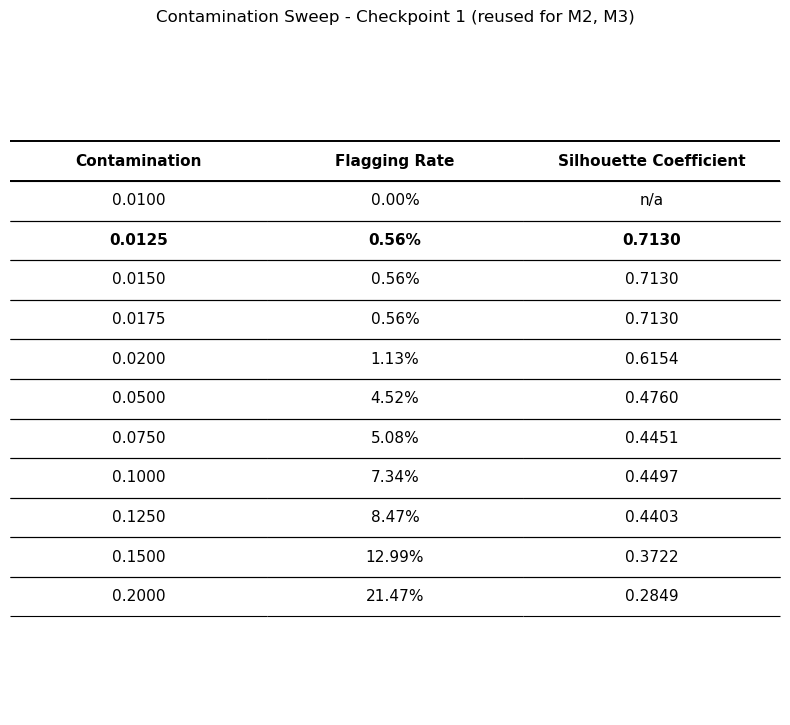

In [7]:
import matplotlib.pyplot as plt

def render_contamination_table(contamination_results, selected_contamination, title):
    df = contamination_results.copy()
    df["contamination"] = df["contamination"].map(lambda v: f"{v:.4f}")
    df["flagging_rate"] = df["flagging_rate"].map(lambda v: f"{v*100:.2f}%")
    df["silhouette"] = df["silhouette"].map(lambda v: "n/a" if pd.isna(v) else f"{v:.4f}")
    df.columns = ["Contamination", "Flagging Rate", "Silhouette Coefficient"]

    highlight_row = contamination_results.index[
        contamination_results["contamination"] == selected_contamination
    ]
    highlight_row = highlight_row[0] if len(highlight_row) else None

    fig, ax = plt.subplots(figsize=(8, 0.55 * len(df) + 1.3))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.0)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
        cell.visible_edges = "horizontal"
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(1.4)
        if highlight_row is not None and row == highlight_row + 1:
            cell.set_facecolor("#d5f5e3")
            cell.set_text_props(weight="bold")

    plt.title(title, fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

render_contamination_table(
    contamination_results, contamination,
    title="Contamination Sweep - Checkpoint 1 (reused for M2, M3)"
)


## Checkpoint 2 -- M2 trained on Batch1+2, SAME contamination reused from checkpoint 1

In [8]:
m2 = IsolationForest(
    n_estimators=100, contamination=contamination,
    max_samples="auto", random_state=RANDOM_SEED,
)
m2.fit(X_cumulative_12_train)

r21 = evaluate_checkpoint(m2, X_cumulative_12_train, X1_test, "R(2,1): M2 on Batch 1 holdout [Backward Transfer check]")
r22 = evaluate_checkpoint(m2, X_cumulative_12_train, X2_test, "R(2,2): M2 on Batch 2 holdout")
r23 = evaluate_checkpoint(m2, X_cumulative_12_train, X3_test, "R(2,3): M2 on Batch 3 holdout [Forward Transfer check]")


--- R(2,1): M2 on Batch 1 holdout [Backward Transfer check] ---
  Flagging Rate         : 0.56%
  Anomaly Score (mean)  : -0.2054 (std 0.0616)
  Silhouette Coefficient: 0.7019

--- R(2,2): M2 on Batch 2 holdout ---
  Flagging Rate         : 1.19%
  Anomaly Score (mean)  : -0.2069 (std 0.0644)
  Silhouette Coefficient: 0.6716

--- R(2,3): M2 on Batch 3 holdout [Forward Transfer check] ---
  Flagging Rate         : 1.34%
  Anomaly Score (mean)  : -0.2116 (std 0.0651)
  Silhouette Coefficient: 0.7699



## Checkpoint 3 -- M3 trained on Batch1+2+3, SAME contamination reused from checkpoint 1

In [9]:
m3 = IsolationForest(
    n_estimators=100, contamination=contamination,
    max_samples="auto", random_state=RANDOM_SEED,
)
m3.fit(X_cumulative_123_train)

r31 = evaluate_checkpoint(m3, X_cumulative_123_train, X1_test, "R(3,1): M3 on Batch 1 holdout [Backward Transfer check]")
r32 = evaluate_checkpoint(m3, X_cumulative_123_train, X2_test, "R(3,2): M3 on Batch 2 holdout [Backward Transfer check]")
r33 = evaluate_checkpoint(m3, X_cumulative_123_train, X3_test, "R(3,3): M3 on Batch 3 holdout")


--- R(3,1): M3 on Batch 1 holdout [Backward Transfer check] ---
  Flagging Rate         : 0.56%
  Anomaly Score (mean)  : -0.2018 (std 0.0608)
  Silhouette Coefficient: 0.7019

--- R(3,2): M3 on Batch 2 holdout [Backward Transfer check] ---
  Flagging Rate         : 0.74%
  Anomaly Score (mean)  : -0.2054 (std 0.0629)
  Silhouette Coefficient: 0.6956

--- R(3,3): M3 on Batch 3 holdout ---
  Flagging Rate         : 1.34%
  Anomaly Score (mean)  : -0.2104 (std 0.0639)
  Silhouette Coefficient: 0.7691



## BWT and FWT

- BWT after checkpoint 2 (same single pairwise difference as the two-checkpoint notebook)
- BWT after checkpoint 3 (averaged over BOTH previously-seen batches, 1 and 2)
- FWT (averaged over each newly-introduced batch's score BEFORE it was trained on)

In [10]:
BWT_2 = r21['silhouette'] - r11['silhouette']
BWT_3 = np.mean([
    r31['silhouette'] - r11['silhouette'],
    r32['silhouette'] - r22['silhouette'],
])
FWT = np.mean([
    r12['silhouette'],   # M1 on Batch 2, before Batch 2 was trained on
    r23['silhouette'],   # M2 on Batch 3, before Batch 3 was trained on
])

print(f"BWT after checkpoint 2 (Batch 1 only)                     : {BWT_2:+.4f}")
print(f"BWT after checkpoint 3 (averaged over Batches 1 and 2)    : {BWT_3:+.4f}")
print(f"FWT (averaged over Batches 2 and 3, each before training) : {FWT:+.4f}")

print()
print("Per-batch BWT trend (is the effect stable, worsening, or recovering across checkpoints?):")
print(f"  Batch 1 holdout: R(1,1)={r11['silhouette']:.4f} -> R(2,1)={r21['silhouette']:.4f} -> R(3,1)={r31['silhouette']:.4f}")
print(f"  Batch 2 holdout: R(2,2)={r22['silhouette']:.4f} -> R(3,2)={r32['silhouette']:.4f}")


BWT after checkpoint 2 (Batch 1 only)                     : +0.0000
BWT after checkpoint 3 (averaged over Batches 1 and 2)    : +0.0120
FWT (averaged over Batches 2 and 3, each before training) : +0.7328

Per-batch BWT trend (is the effect stable, worsening, or recovering across checkpoints?):
  Batch 1 holdout: R(1,1)=0.7019 -> R(2,1)=0.7019 -> R(3,1)=0.7019
  Batch 2 holdout: R(2,2)=0.6716 -> R(3,2)=0.6956


## Firewall rule generation -- most current model (M3)

In [11]:
from adaptrap_pipeline import get_representative_ports, generate_rules

port_lookup_b3 = get_representative_ports(BATCH_3_PATH)

rules_m3_batch3 = generate_rules(
    m3, X3_test, batch3_profiles.iloc[b3_test_idx], port_lookup_b3,
    label="M3 (Adaptive) on Batch 3 holdout"
)


--- M3 (Adaptive) on Batch 3 holdout ---
         source_ip     port  anomaly_score               action
0    34.205.13.154  35274.0       0.112060  ESCALATE_TO_ANALYST
1     140.82.112.3  41134.0       0.101214  ESCALATE_TO_ANALYST
2    151.101.1.229  33092.0       0.073731  ESCALATE_TO_ANALYST
3  120.233.173.250   5555.0       0.065589  ESCALATE_TO_ANALYST
4       42.48.4.58   1433.0       0.051510  ESCALATE_TO_ANALYST
5    1.179.128.124   1433.0       0.051234  ESCALATE_TO_ANALYST
6   103.239.252.66   1433.0       0.036882  ESCALATE_TO_ANALYST
7    79.124.56.106   5900.0       0.019434  ESCALATE_TO_ANALYST
8   193.105.134.95     22.0       0.008740  ESCALATE_TO_ANALYST
9  217.182.198.219   8888.0       0.003443  ESCALATE_TO_ANALYST

ESCALATE_TO_ANALYST: 247, ALLOW: 575
(No records are auto-blocked. BLOCK is an analyst decision made after reviewing an ESCALATE_TO_ANALYST record, not an automated label.)
